# Classification Dataset Generation

The `artificial_dataset` package builds labelled datasets by composing
four signal primitives: **Gaussian noise**, **linear**, **polynomial**,
and **sinusoidal**, each with class-specific parameters.

This notebook demonstrates:
- A default two-class dataset
- A three-class dataset with custom component parameters
- How noise level affects class separability
- The four individual signal primitives in isolation

In [ ]:
import math

import matplotlib.pyplot as plt
import torch

from artificial_dataset import (
    ClassifierMetrics,
    gaussian_noise,
    linear,
    make_classification,
    polynomial,
    sinusoidal,
)

## Default two-class dataset

Each class is defined by a different combination of sinusoidal and linear
components. A small amount of Gaussian noise is added to every sample.

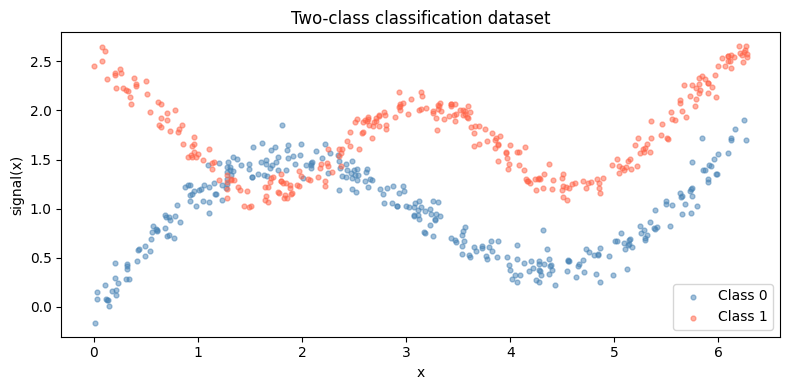

In [2]:
X, y = make_classification(n_samples=600, n_classes=2, noise_std=0.1, random_state=0)

fig, ax = plt.subplots(figsize=(8, 4))
for cls, color in enumerate(["steelblue", "tomato"]):
    mask = y == cls
    ax.scatter(
        X[mask, 0],
        X[mask, 1],
        s=12,
        alpha=0.5,
        color=color,
        label=f"Class {cls}",
    )
ax.set_xlabel("x")
ax.set_ylabel("signal(x)")
ax.set_title("Two-class classification dataset")
ax.legend()
plt.tight_layout()
plt.show()

## Three-class dataset with custom component parameters

Each class receives an explicit component configuration: a `dict` with keys
`"linear"`, `"polynomial"`, and/or `"sinusoidal"`, mapping to keyword
arguments for the corresponding primitive.

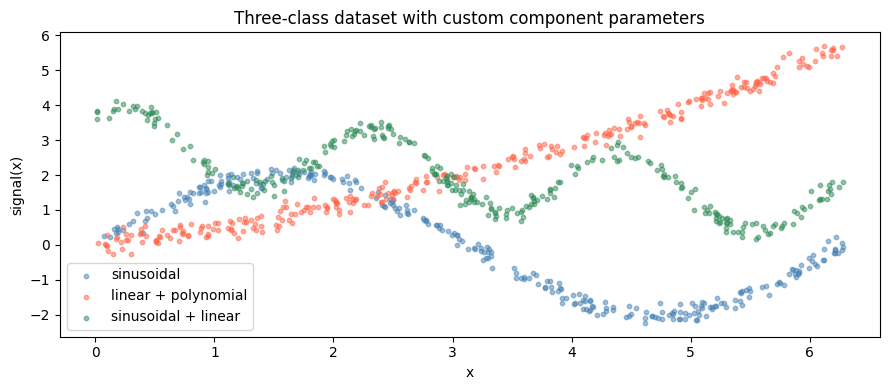

In [3]:
class_params = [
    {"sinusoidal": {"amplitude": 2.0, "frequency": 1.0, "phase": 0.0}},
    {
        "linear": {"slope": 0.4, "intercept": 0.0},
        "polynomial": {"coefficients": [0.0, 0.0, 0.08]},
    },
    {
        "sinusoidal": {"amplitude": 1.0, "frequency": 3.0, "phase": math.pi / 4},
        "linear": {"slope": -0.3, "intercept": 3.0},
    },
]

X3, y3 = make_classification(
    n_samples=900,
    n_classes=3,
    noise_std=0.15,
    class_params=class_params,
    random_state=1,
)

colors = ["steelblue", "tomato", "seagreen"]
component_labels = ["sinusoidal", "linear + polynomial", "sinusoidal + linear"]

fig, ax = plt.subplots(figsize=(9, 4))
for cls in range(3):
    mask = y3 == cls
    ax.scatter(
        X3[mask, 0],
        X3[mask, 1],
        s=10,
        alpha=0.5,
        color=colors[cls],
        label=component_labels[cls],
    )
ax.set_xlabel("x")
ax.set_ylabel("signal(x)")
ax.set_title("Three-class dataset with custom component parameters")
ax.legend()
plt.tight_layout()
plt.show()

## Effect of noise on class separability

`noise_std` controls how much Gaussian noise is added to the deterministic
signal. Low values keep classes well-separated; high values blur them.

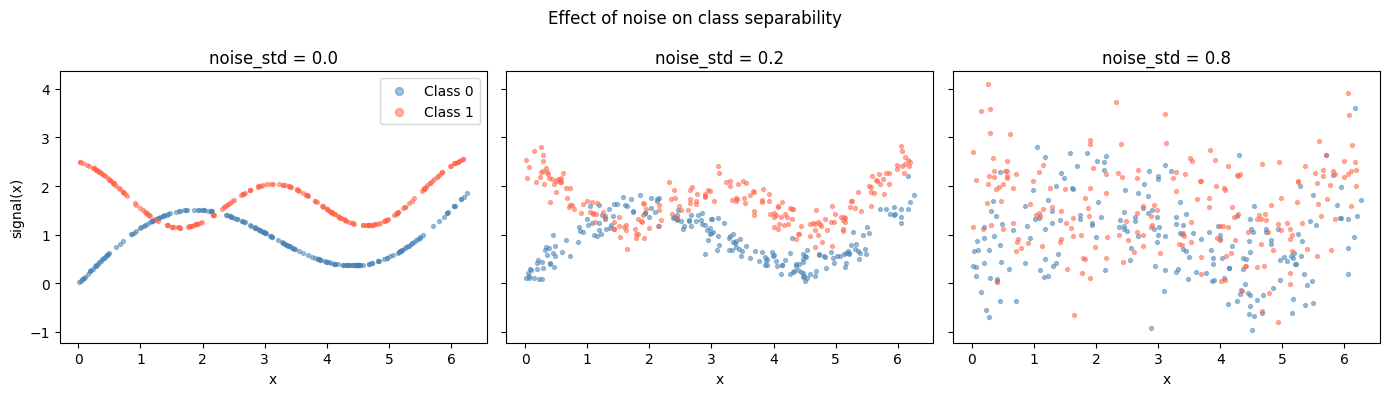

In [4]:
noise_levels = [0.0, 0.2, 0.8]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for i, std in enumerate(noise_levels):
    X_n, y_n = make_classification(n_samples=400, noise_std=std, random_state=2)
    for cls, color in enumerate(["steelblue", "tomato"]):
        mask = y_n == cls
        axes[i].scatter(
            X_n[mask, 0],
            X_n[mask, 1],
            s=8,
            alpha=0.5,
            color=color,
            label=f"Class {cls}",
        )
    axes[i].set_title(f"noise_std = {std}")
    axes[i].set_xlabel("x")
axes[0].set_ylabel("signal(x)")
axes[0].legend(markerscale=2)
plt.suptitle("Effect of noise on class separability")
plt.tight_layout()
plt.show()

## Individual signal primitives

The four building blocks available for composing class distributions,
evaluated on a shared input grid.

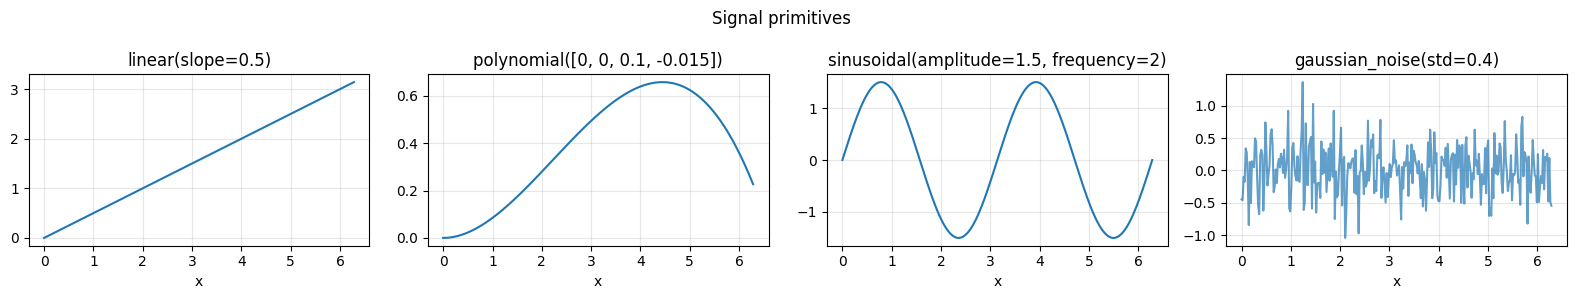

In [5]:
x = torch.linspace(0, 2 * math.pi, 300)

fig, axes = plt.subplots(1, 4, figsize=(16, 3))

axes[0].plot(x, linear(x, slope=0.5, intercept=0.0))
axes[0].set_title("linear(slope=0.5)")

axes[1].plot(x, polynomial(x, coefficients=[0.0, 0.0, 0.1, -0.015]))
axes[1].set_title("polynomial([0, 0, 0.1, -0.015])")

axes[2].plot(x, sinusoidal(x, amplitude=1.5, frequency=2.0, phase=0.0))
axes[2].set_title("sinusoidal(amplitude=1.5, frequency=2)")

torch.manual_seed(0)
axes[3].plot(x, gaussian_noise((300,), std=0.4), alpha=0.7)
axes[3].set_title("gaussian_noise(std=0.4)")

for ax in axes:
    ax.set_xlabel("x")
    ax.grid(alpha=0.3)
plt.suptitle("Signal primitives")
plt.tight_layout()
plt.show()

## Evaluating a classifier with `ClassifierMetrics`

`ClassifierMetrics` accepts full `y_true` / `y_pred` label tensors and
computes accuracy, macro-averaged precision, recall, F1, and a confusion
matrix.  All per-class metrics are macro-averaged over the unique classes
found in both vectors.

In [ ]:
# Generate a three-class dataset and simulate imperfect predictions.
X_ev, y_true = make_classification(
    n_samples=600, n_classes=3, noise_std=0.15, random_state=7
)

# Simulate a classifier: correct 85% of the time, random errors otherwise.
torch.manual_seed(1)
noise_mask = torch.rand(len(y_true)) < 0.15
y_pred = y_true.clone()
y_pred[noise_mask] = torch.randint(0, 3, (noise_mask.sum().item(),))

m = ClassifierMetrics(y_true, y_pred)

print(f"Accuracy  : {m.accuracy:.3f}")
print(f"Precision : {m.precision:.3f}  (macro-averaged)")
print(f"Recall    : {m.recall:.3f}  (macro-averaged)")
print(f"F1 score  : {m.f1_score:.3f}  (macro-averaged)")
print()
print("Confusion matrix (rows = true class, cols = predicted class):")
print(m.confusion_matrix)